In [40]:
# AI was used to assist code development
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [41]:
full_charging_df = pd.read_feather("../data/full_charging_df.feather")
pd.set_option('display.max_columns', None)
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,inputCount,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,doneDisconnectTimespan,connectionTimespan,doneChargingTimespan,connectionMonth,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected,invalidDoneDisconnectTimespan
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,1,250.0,25.0,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00,0 days 01:39:40,0 days 06:02:21,0 days 04:22:41,1,Thursday,2020,False,5,11,9,262.683333,362.350000,0.724944,False
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,1,280.0,70.0,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00,0 days 02:20:16,0 days 09:01:31,0 days 06:41:15,1,Thursday,2020,False,5,14,12,401.250000,541.516667,0.740974,False
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,1,400.0,8.0,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00,0 days 08:04:16,0 days 10:42:47,0 days 02:38:31,1,Thursday,2020,False,5,16,8,158.516667,642.783333,0.246610,False
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,2,400.0,8.0,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00,0 days 01:19:54,0 days 02:38:41,0 days 01:18:47,1,Thursday,2020,False,5,8,7,78.783333,158.683333,0.496481,False
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,1,400.0,16.0,40.0,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00,0 days 03:51:10,0 days 08:08:39,0 days 04:17:29,1,Thursday,2020,False,6,14,10,257.483333,488.650000,0.526928,False


### Selection of features

Since the task is to find clusters for archetypical charging sessions and not for how requests from registered users deviate from the actual charging session, we decided to only incorporate features that are not in the user inputs. Moreover, we calculated two measures from connectionTime, disconnectTime and doneChargingTime. The charging_duration is the timespan between connectionTime and doneChargingTime and the idle_time is the timespan from doneChargingTime to disconnectTime. With this calculation we decreased dimensionality from 4 to only 3 explainable features.

NOTES:
- Started with selection of relevant features and exploration

In [42]:
# Calculate timespans
full_charging_df['session_duration'] = (full_charging_df['disconnectTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
full_charging_df['charging_duration'] = (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
full_charging_df['idle_time'] = (full_charging_df['disconnectTime'] - full_charging_df['doneChargingTime']).dt.total_seconds() / 60

In [43]:
# Select features for clustering
relevantFeatures = [
    'session_duration',
    'charging_duration',
    'idle_time',
    'kWhRequested',
    'kWhDelivered',
    'minutesAvailable',
]

NOTES:
- Dropping values significantly reduces data size
- Quickly explain why just drop values

In [44]:
X = full_charging_df[relevantFeatures].dropna()

# Compare sizes before and after dropping NaNs
print(full_charging_df[relevantFeatures].shape)
print(X.shape)

(60921, 6)
(44636, 6)


NOTES:
- Used StandardScaler to standardize features for kMeans -> Normalization

In [45]:
scaler = StandardScaler()
scaler.fit(X)
clustering_scaled = scaler.transform(X)
clustering_scaled_df = pd.DataFrame(clustering_scaled, columns=X.columns, index=X.index)
clustering_scaled_df.head()

,session_duration,charging_duration,idle_time,kWhRequested,kWhDelivered,minutesAvailable
0,-0.149964,0.242576,-0.374522,0.002295,1.086228,0.549890
1,0.543793,1.040220,-0.186495,2.177295,1.834886,1.219693
2,0.935910,-0.357047,1.406634,-0.819371,-0.627227,-1.495039
3,-0.938588,-0.816023,-0.466065,-0.819371,-1.013183,-1.469668
4,0.339086,0.212643,0.234480,-0.432705,0.007756,0.757935


NOTES:
- fit kMeans model
- using kMeans++ model -> explain why
- did not use Hierarchical Clustering due to large data size and high computational complexity -> n^3
- did not use Soft Clustering to provide clearer advice for the management
    - In Soft Clustering clusters can be apart of multiple clusters -> in our scenario it does not make much sense that one session can be a part of multiple clusters
    - Less clear and straightforward

In [46]:
k_max = 20
clusters = []
losses = []

for k in range(k_max):
    model = KMeans(n_clusters=k+1, n_init='auto', random_state=42)
    model.fit(clustering_scaled_df)
    clusters.append(k+1)
    losses.append(model.inertia_)

NOTES:
- Plotting the loss to find optimal number of clusters

NOTES:
- Optimal number of clusters between 2 and 13

(np.float64(0.04999999999999993), np.float64(20.95))

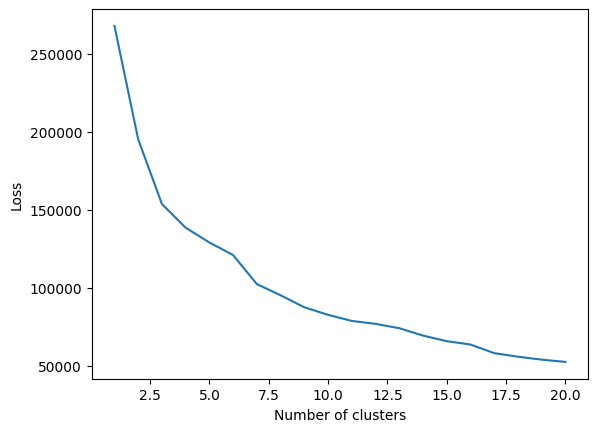

In [47]:
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.xlim()

In [48]:
# refit algorithm
seven_means = KMeans(n_clusters=7, n_init='auto', random_state=42)
seven_means.fit(clustering_scaled_df)
seven_means.predict(clustering_scaled_df)

array([5, 4, 0, ..., 3, 3, 3], dtype=int32)

NOTES:
- Plotting 7 Clusters initially and exploring them -> needs some describing

/Users/dc/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-CRfD5Dnf-py3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


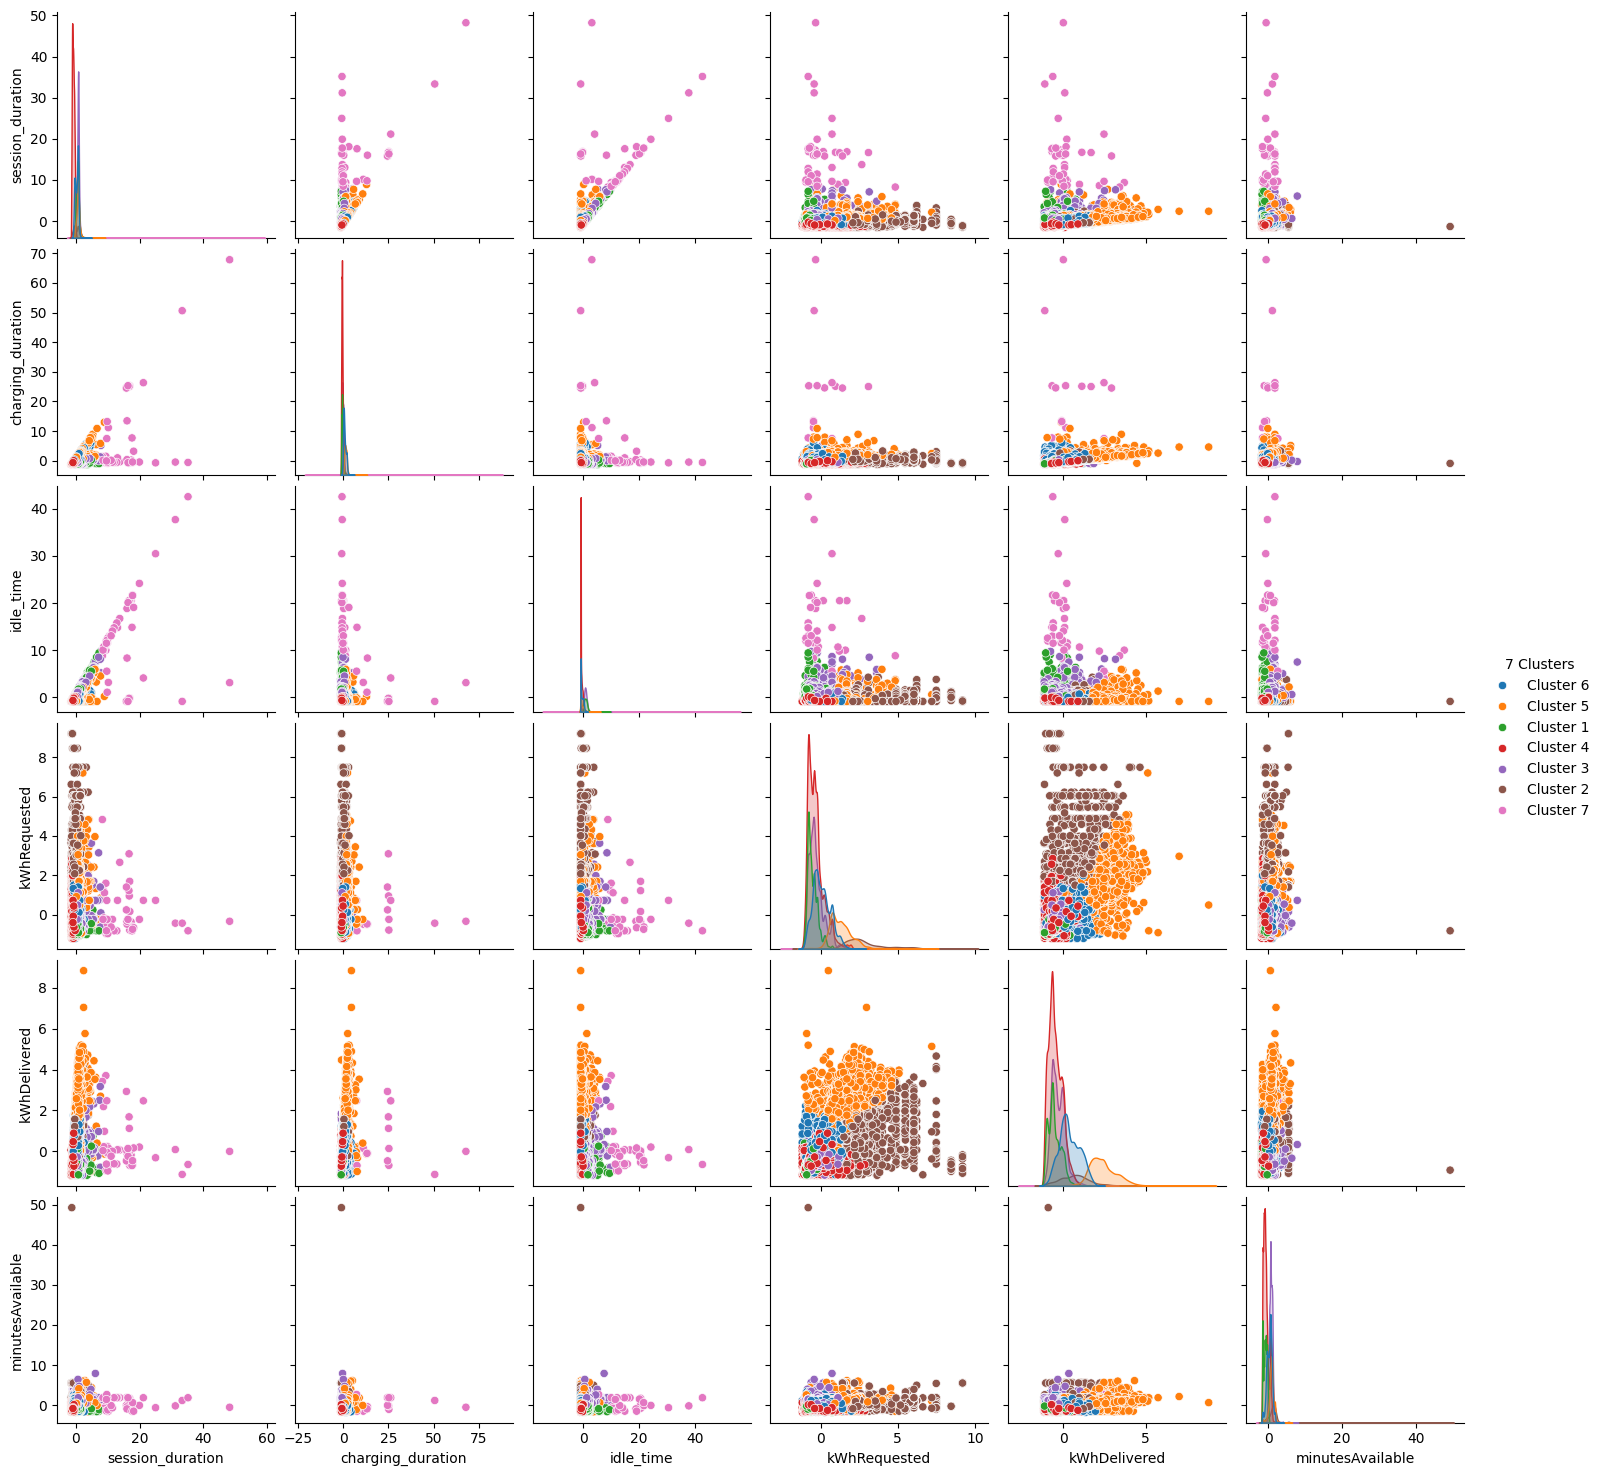

In [49]:
numbers = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5", "Cluster 6", "Cluster 7"]


# TEMP: Commented out for speed

clustering_scaled_df["7 Clusters"] = seven_means.predict(clustering_scaled)
clustering_scaled_df["7 Clusters"] = clustering_scaled_df["7 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=clustering_scaled_df, hue="7 Clusters")

NOTES:
- Correlation Matrix of features to identify which dimensions to reduce and picking only the most relevant two
- for explainability and clear advice for the management
- e.g. Correlation between charging duration and kWhDelivered: 0.5319936654405534

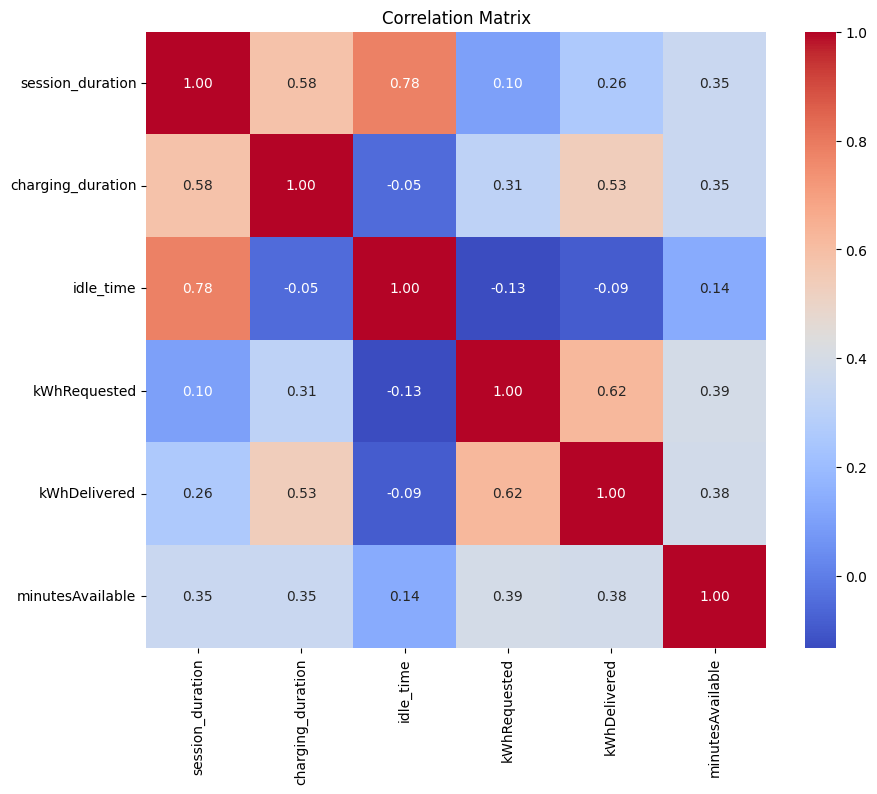

In [50]:
# Correlation Matrix Heatmap
correlation_matrix = full_charging_df[relevantFeatures].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

NOTES:
- Reduced to only these 2 features -> explain why
- Doing the same thing as initially with the 7 Clusters but with only these 2 features

In [51]:
# Select features for clustering
features = [
    'session_duration',
    'kWhDelivered'
]

In [52]:
# Drop rows with NaN values
X = full_charging_df[features].dropna()

# Compare sizes before and after dropping NaNs
print(full_charging_df[features].shape)
print(X.shape)

X.head()

(60921, 2)
(60921, 2)


,session_duration,kWhDelivered
0,362.350000,25.016
1,541.516667,33.097
2,642.783333,6.521
3,158.683333,2.355
4,488.650000,13.375


In [53]:
scaler = StandardScaler()
scaler.fit(X)
clustering_scaled = scaler.transform(X)
clustering_scaled_df = pd.DataFrame(clustering_scaled, columns=X.columns, index=X.index)
clustering_scaled_df.head()

,session_duration,kWhDelivered
0,-0.068737,1.322509
1,0.538972,2.118370
2,0.882455,-0.498978
3,-0.759547,-0.909269
4,0.359656,0.176041


In [54]:
k_max = 15
clusters = []
losses = []

for k in range(k_max):
    model = KMeans(n_clusters=k+1, n_init='auto', random_state=42)
    model.fit(clustering_scaled_df)
    clusters.append(k+1)
    losses.append(model.inertia_)

NOTES:
- Optimal number of clusters between 2 and 8

(0.0, 14.0)

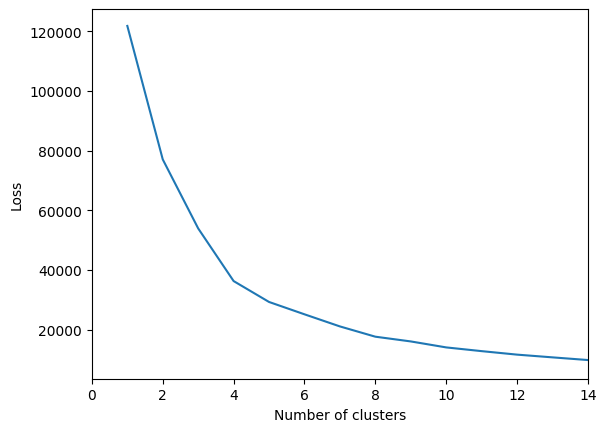

In [55]:
# Plot the loss curve to find the optimal number of clusters
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.xlim([0,14])

NOTES:
- Start with 5 clusters -> explain why

In [56]:
numbers = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4", "Cluster 5"]

/Users/dc/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-CRfD5Dnf-py3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


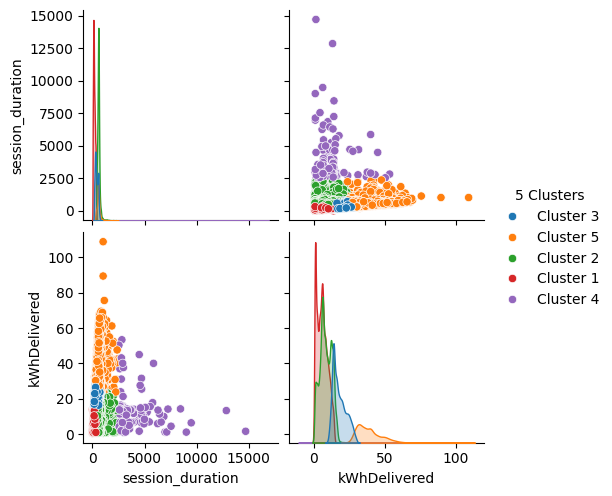

In [57]:
# Test with 5 clusters first

five_means = KMeans(n_clusters=5, n_init='auto', random_state=42)
# Fit algorithm for 5 clusters
five_means.fit(clustering_scaled_df)
X["5 Clusters"] = five_means.predict(clustering_scaled)
X["5 Clusters"] = X["5 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=X, hue="5 Clusters")

NOTES:
- what do these 5 clusters tell us
- Try again with 4 clusters

/Users/dc/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-CRfD5Dnf-py3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


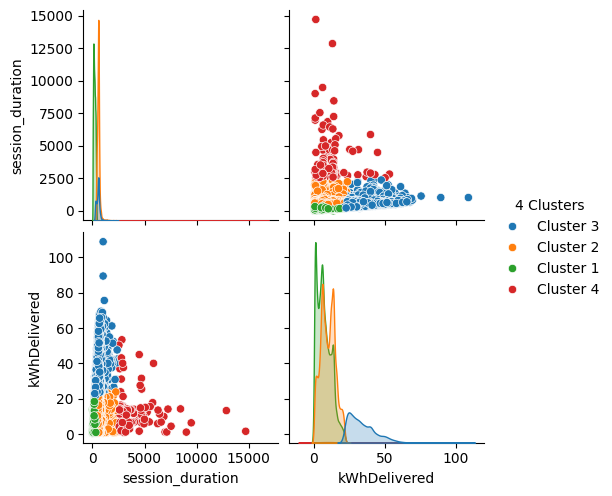

In [58]:
four_means = KMeans(n_clusters=4, n_init='auto', random_state=42)
# Fit algorithm for 4 clusters
four_means.fit(clustering_scaled_df)
X["4 Clusters"] = four_means.predict(clustering_scaled)
X["4 Clusters"] = X["4 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=X, hue="4 Clusters")

NOTES:
- 4 Clusters looking good

<h4>Cluster Description</h4>
<p><b>Cluster 1: Medium Charge </b>-> Charging Events with a medium high session_duration and an average kWh_delivered</p>
<p><b>Cluster 2: Quick Session </b>-> Short charging time with relatively low energy consumption </p>
<p><b>Cluster 3: Power Charge </b>-> Use the highest amount of energy, but are connected within a regular session duration</p>
<p><b>Cluster 4: Long Idle </b>-> Stays connected for a long time, but doesn't charge the whole time</p>

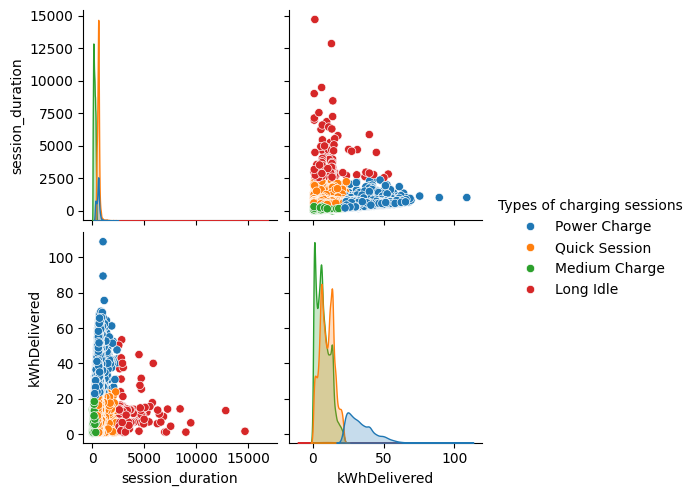

In [59]:
# Rename labels in plot

# New labels
new_mappings = {
    "Cluster 1": "Medium Charge",
    "Cluster 2": "Quick Session",
    "Cluster 3": "Power Charge",
    "Cluster 4": "Long Idle"
}

# Replace cluster names based on the mapping
charging_session_types = "Types of charging sessions"
X[charging_session_types] = X["4 Clusters"].replace(new_mappings)

# Plot with the new labels
sns.pairplot(data=X, hue=charging_session_types)


NOTES:
- Distribution of 4 Clusters

Types of charging sessions
Medium Charge    27603
Quick Session    25668
Power Charge      7528
Long Idle          122
Name: count, dtype: int64


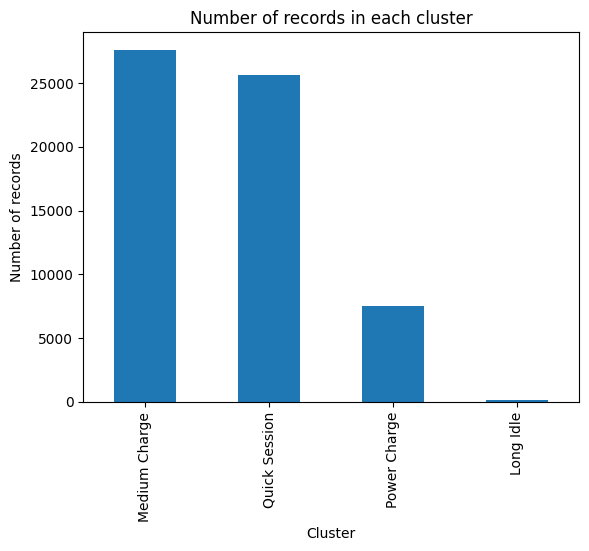

In [60]:
# Length of each cluster
print(X[charging_session_types].value_counts())

# Bar Chart plot
X[charging_session_types].value_counts().plot(kind='bar')
plt.title("Number of records in each cluster")
plt.ylabel("Number of records")
plt.xlabel("Cluster")
plt.show()

NOTES:
- Very few in cluster "Long Idle" -> mostly outliers / exceptions

In [61]:
# kWhDelivered statistics for each cluster
X.groupby(charging_session_types)["kWhDelivered"].describe()

,count,mean,std,min,25%,50%,75%,max
Types of charging sessions,,,,,,,,
Long Idle,122.0,12.247177,10.210641,0.896,6.44975,11.2600,13.9825,53.282000
Medium Charge,27603.0,7.176008,4.932431,0.501,3.08050,6.2710,10.6725,22.430000
Power Charge,7528.0,33.719568,9.260238,21.260,26.11600,31.6935,39.7480,108.797242
Quick Session,25668.0,9.837498,5.024752,0.506,5.90375,9.6880,13.6170,23.871000


In [62]:
# session_duration statistics for each cluster
X.groupby(charging_session_types)["session_duration"].describe()

,count,mean,std,min,25%,50%,75%,max
Types of charging sessions,,,,,,,,
Long Idle,122.0,4116.676503,1936.908063,2344.583333,2830.962500,3619.983333,4746.633333,14716.150000
Medium Charge,27603.0,171.547715,94.322861,3.050000,93.000000,162.316667,245.675000,407.466667
Power Charge,7528.0,510.476333,185.737556,193.800000,384.566667,525.991667,589.016667,2394.000000
Quick Session,25668.0,554.346579,143.055792,289.833333,480.966667,548.950000,600.566667,2331.633333


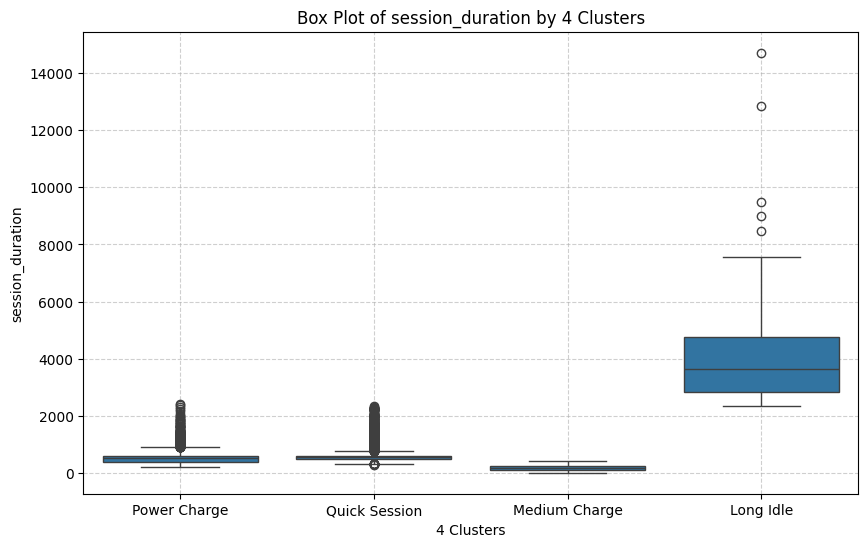

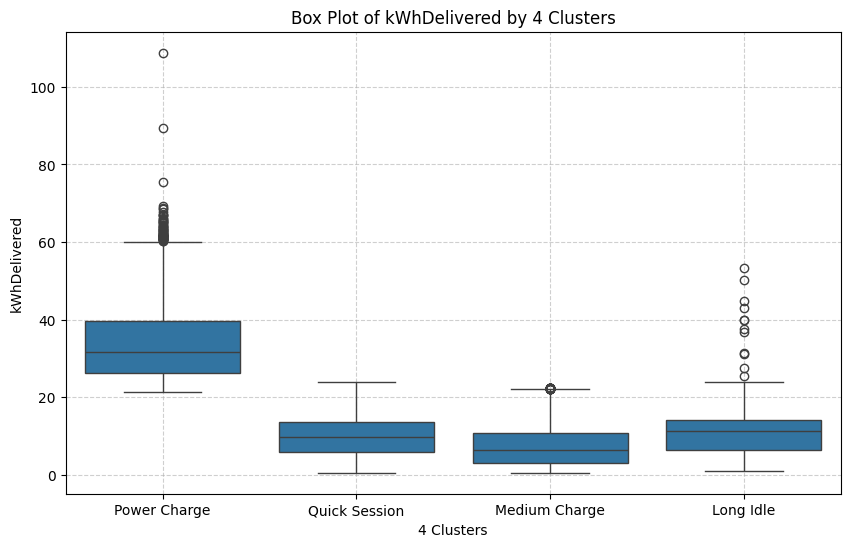

In [63]:
# Box Whisker plot
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=X, x=charging_session_types, y=feature)
    plt.title(f'Box Plot of {feature} by 4 Clusters')
    plt.xlabel('4 Clusters')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [64]:
# Distribution of kWhDelivered and session_duration for the whole dataset
X[features].describe()

,session_duration,kWhDelivered
count,60921.000000,60921.000000
mean,382.615189,11.587520
std,294.825516,10.153871
min,3.050000,0.501000
25%,178.450000,5.018000
50%,378.500000,8.995000
75%,554.450000,13.984000
max,14716.150000,108.797242


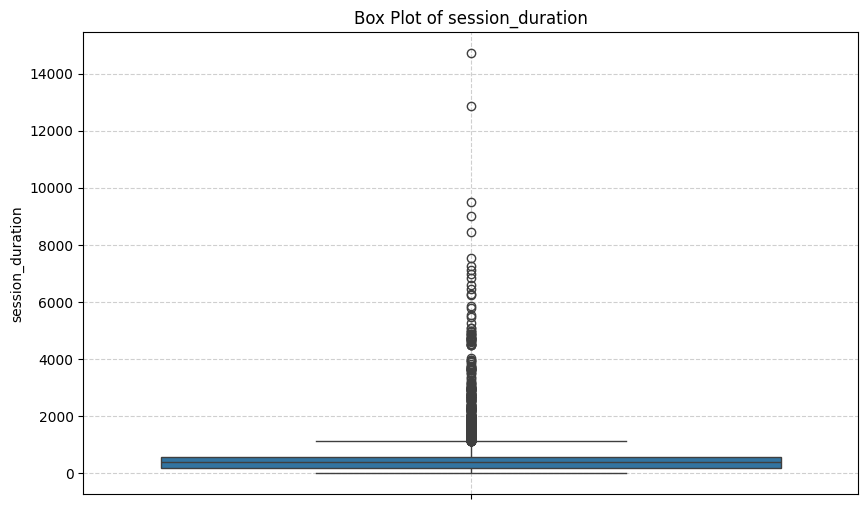

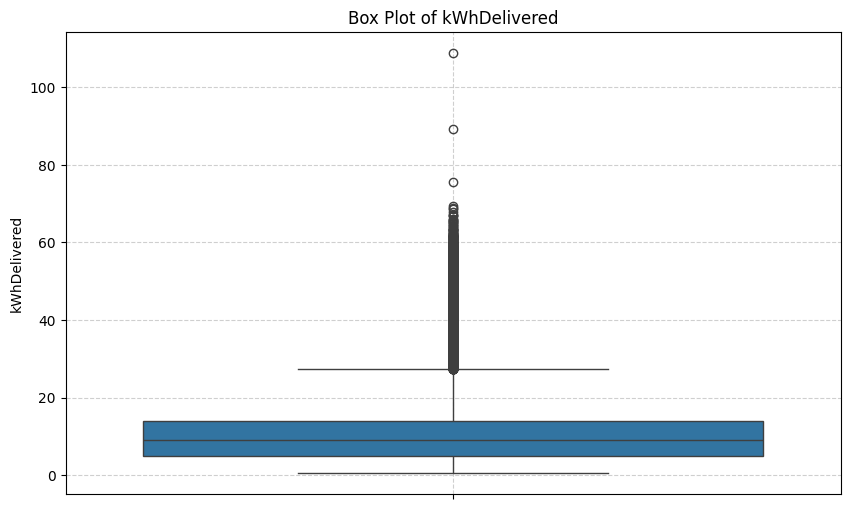

In [65]:
# Box Whisker plot
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=X, y=feature)
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [66]:
# user_df is the same as full charging df but the columns are dropped where the features are nan
# user_df is specified here for merging the userIDs back to the clusters dataframe in the next steps
user_df = full_charging_df.dropna(subset=features)
print(X.shape)
print(user_df.shape)

(60921, 5)
(60921, 36)


NOTES:
- Steps to calculate dominant clusters for each user
- only include users that had at least 10 sessions
- acknowledge that number of rows in the fit kMeans differs now because rows without userIDs are dropped

In [67]:
# Append clusters column to user_df
user_df[charging_session_types] = X[charging_session_types]

# Group by userID and calculate session count
user_session_counts = user_df.groupby('userID').size()

# Filter users with at least 10 sessions
valid_user_ids = user_session_counts[user_session_counts >= 5].index
user_df = user_df[user_df['userID'].isin(valid_user_ids)]

In [68]:
# Check cluster consistency for each userID
user_cluster_stats = (
    user_df.groupby('userID')[charging_session_types]
    .value_counts(normalize=True)  # Get proportion of sessions in each cluster
    .reset_index(name='proportion')
)

user_cluster_stats

,userID,Types of charging sessions,proportion
0,22.0,Quick Session,0.368421
1,22.0,Medium Charge,0.350877
2,22.0,Power Charge,0.280702
3,58.0,Power Charge,0.800000
4,58.0,Medium Charge,0.200000
...,...,...,...
1416,17953.0,Medium Charge,0.833333
1417,17953.0,Quick Session,0.166667
1418,18886.0,Medium Charge,0.400000
1419,18886.0,Power Charge,0.400000


NOTES:
- Only include users that clearly fall into the same cluster at least 80% of the time
- 39.89% of the users have a dominant cluster (at least 10 sessions and 80% requirement)

In [69]:
# Find the dominant cluster for each user
dominant_clusters = user_cluster_stats.loc[user_cluster_stats.groupby('userID')['proportion'].idxmax()].reset_index(drop=True)

# Only keep users where the dominant cluster is more than 80% of their sessions
dominant_clusters = dominant_clusters[dominant_clusters['proportion'] >= 0.8]

# Percentage of users with a dominant cluster
percentage_dominant = dominant_clusters.shape[0] / user_df['userID'].nunique() * 100
print(f"Percentage of users with a dominant cluster: {percentage_dominant:.2f}%")

# Rename the columns for clarity
dominant_clusters = dominant_clusters.rename(columns={charging_session_types: 'dominant_cluster', 'proportion': 'consistency_score'})

dominant_clusters

Percentage of users with a dominant cluster: 40.25%


,userID,dominant_cluster,consistency_score
1,58.0,Power Charge,0.800000
2,61.0,Quick Session,0.837209
4,67.0,Power Charge,0.803571
6,69.0,Quick Session,0.815789
7,76.0,Medium Charge,0.963158
...,...,...,...
621,15756.0,Medium Charge,1.000000
623,16140.0,Quick Session,1.000000
626,17097.0,Medium Charge,0.800000
628,17752.0,Quick Session,1.000000


In [70]:
# Calculate the total number of users
total_users = dominant_clusters['dominant_cluster'].value_counts().sum()
print(total_users)

# Add a percentage column
cluster_counts = dominant_clusters['dominant_cluster'].value_counts().reset_index()
cluster_counts.columns = ['dominant_cluster', 'count']
cluster_counts['percentage'] = (cluster_counts['count'] / total_users) * 100
cluster_counts

254


,dominant_cluster,count,percentage
0,Medium Charge,130,51.181102
1,Quick Session,91,35.826772
2,Power Charge,33,12.992126


NOTES:
- Most can be identified as Quick Session & Medium Charge -> Focus on these 2 Clusters
- Long Idle non existent -> Only exceptions and outliers
- Power Charge are minority -> Maybe charge premium prices?
- Again acknowledge these requirements: at least 10 sessions and 80% of the sessions in the same cluster and has userID

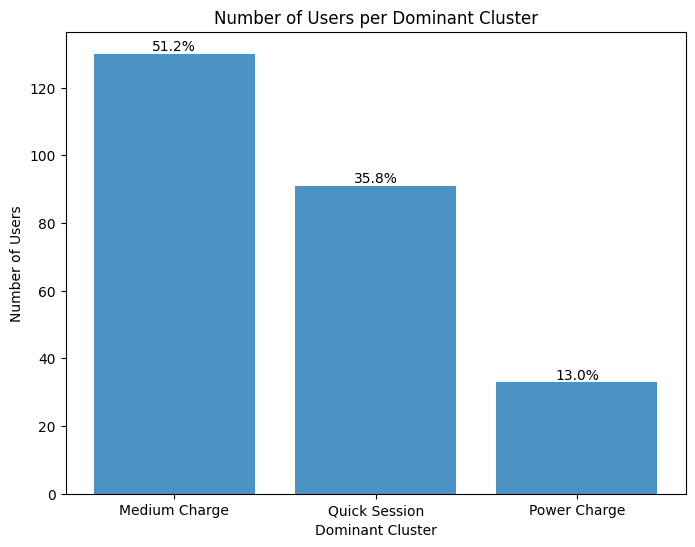

In [71]:
# Plot the counts
plt.figure(figsize=(8, 6))
plt.bar(cluster_counts['dominant_cluster'], cluster_counts['count'], alpha=0.8, label='Count')

# Add percentages on top of the bars
for i, row in cluster_counts.iterrows():
    plt.text(row['dominant_cluster'], row['count'], f"{row['percentage']:.1f}%", ha='center', va='bottom')

# Add labels and title
plt.xlabel('Dominant Cluster')
plt.ylabel('Number of Users')
plt.title('Number of Users per Dominant Cluster')
plt.show()

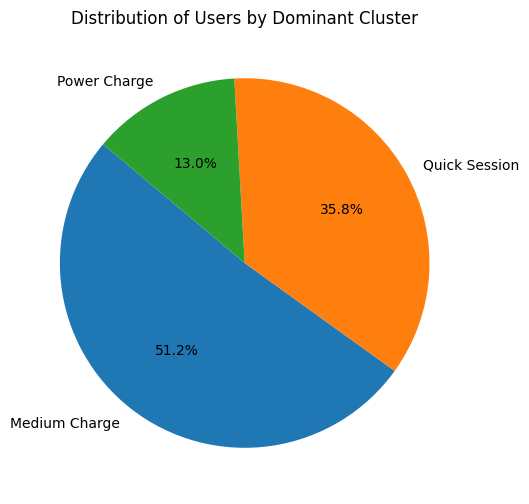

In [72]:
# Pie chart
plt.figure(figsize=(8, 6))
plt.pie(cluster_counts['percentage'], labels=cluster_counts['dominant_cluster'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Users by Dominant Cluster')
plt.show()